In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from torchvision.transforms import ToTensor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [ ]:
train_df=pd.read_csv('train.csv')
train_df.shape

(42000, 785)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(train_df.drop('label',axis=1),train_df['label'],test_size=0.2,random_state=42)

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = torch.tensor(labels,dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        sample=sample.reshape(28,28)
        labels=self.labels[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample,labels


In [ ]:
X_train=X_train.values.astype(np.float32)
y_train=y_train.values.astype(np.float32)
X_test=X_test.values.astype(np.float32)
y_test=y_test.values.astype(np.float32)

In [ ]:
dataset=CustomDataset(X_train,y_train,transform=ToTensor())
test_dataset=CustomDataset(X_test,y_test,transform=ToTensor())

In [ ]:
sample,label=dataset[0]

In [ ]:
label=label.view(-1)

In [ ]:
import torch
import torch.nn as nn

# CNN with custom activation
class CNN(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super(CNN, self).__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1),
            activation(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            activation(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*14*14, 128),
            activation(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.sequential(x)
        x = self.classifier(x)
        return x


# MLP with custom activation
class MLP(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super(MLP, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            activation(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            activation(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.classifier(x)
        return x


# Larger MLP with custom activation
class MLP512(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super(MLP512, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            activation(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            activation(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            activation(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.classifier(x)
        return x


In [ ]:
train_loader=DataLoader(dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using Device:", device)
criterion = nn.CrossEntropyLoss()
# Learning rate
lr = 0.001

# List of activation functions
activation_list = [nn.ReLU, nn.Tanh, nn.Sigmoid]

# Configuration dictionary with activations as a list
model_config = {
    "CNN-1": {
        "activations": activation_list,
        "epochs": 10,
        "optim_type": "Adam"
    },
    "MLP-1": {
        "activations": activation_list,
        "epochs": 20,
        "optim_type": "SGD"
    },
    "MLP-2": {
        "activations": activation_list,
        "epochs": 15,
        "optim_type": "Adam"
    }
}


Using Device: cuda


In [ ]:
# Initialize results dictionary
model_results_config = {}

for model_name, config in model_config.items():
    model_results_config[model_name] = {}

    for activation in config["activations"]:
        act_name = activation.__name__
        print(f"\nTraining {model_name} with activation {act_name}")

        if model_name == "CNN-1":
            model = CNN(activation=activation).to(device)
        elif model_name == "MLP-1":
            model = MLP(activation=activation).to(device)
        elif model_name == "MLP-2":
            model = MLP512(activation=activation).to(device)
        else:
            continue

        # Instantiate optimizer
        if config["optim_type"] == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr)
        else:
            optimizer = optim.SGD(model.parameters(), lr=lr)

        epochs = config["epochs"]

        # Store metrics for this activation
        model_results_config[model_name][act_name] = {"epochs_losses": [], "epochs_accuracy": []}

        # Training loop
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for data, targets in train_loader:
                data, targets = data.to(device), targets.to(device)

                # Forward
                scores = model(data)
                loss = criterion(scores, targets)

                # Backward
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Accumulate loss and accuracy
                running_loss += loss.item() * data.size(0)  # sum over batch
                _, predictions = torch.max(scores, 1)
                correct += (predictions == targets).sum().item()
                total += targets.size(0)

            # Compute averages
            epoch_loss = running_loss / total
            epoch_accuracy = correct / total

            # Store metrics
            model_results_config[model_name][act_name]["epochs_losses"].append(epoch_loss)
            model_results_config[model_name][act_name]["epochs_accuracy"].append(epoch_accuracy)

            print(f"{model_name} | {act_name} | Epoch [{epoch+1}/{epochs}] "
                  f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")



Training CNN-1 with activation ReLU
CNN-1 | ReLU | Epoch [1/10] Loss: 0.4841, Accuracy: 0.8970
CNN-1 | ReLU | Epoch [2/10] Loss: 0.1761, Accuracy: 0.9490
CNN-1 | ReLU | Epoch [3/10] Loss: 0.1391, Accuracy: 0.9590
CNN-1 | ReLU | Epoch [4/10] Loss: 0.1222, Accuracy: 0.9640
CNN-1 | ReLU | Epoch [5/10] Loss: 0.1051, Accuracy: 0.9683
CNN-1 | ReLU | Epoch [6/10] Loss: 0.0951, Accuracy: 0.9706
CNN-1 | ReLU | Epoch [7/10] Loss: 0.0870, Accuracy: 0.9729
CNN-1 | ReLU | Epoch [8/10] Loss: 0.0871, Accuracy: 0.9739
CNN-1 | ReLU | Epoch [9/10] Loss: 0.0783, Accuracy: 0.9771
CNN-1 | ReLU | Epoch [10/10] Loss: 0.0738, Accuracy: 0.9787

Training CNN-1 with activation Tanh
CNN-1 | Tanh | Epoch [1/10] Loss: 0.2062, Accuracy: 0.9412
CNN-1 | Tanh | Epoch [2/10] Loss: 0.1222, Accuracy: 0.9634
CNN-1 | Tanh | Epoch [3/10] Loss: 0.1159, Accuracy: 0.9643
CNN-1 | Tanh | Epoch [4/10] Loss: 0.1147, Accuracy: 0.9645
CNN-1 | Tanh | Epoch [5/10] Loss: 0.1123, Accuracy: 0.9648
CNN-1 | Tanh | Epoch [6/10] Loss: 0.1085

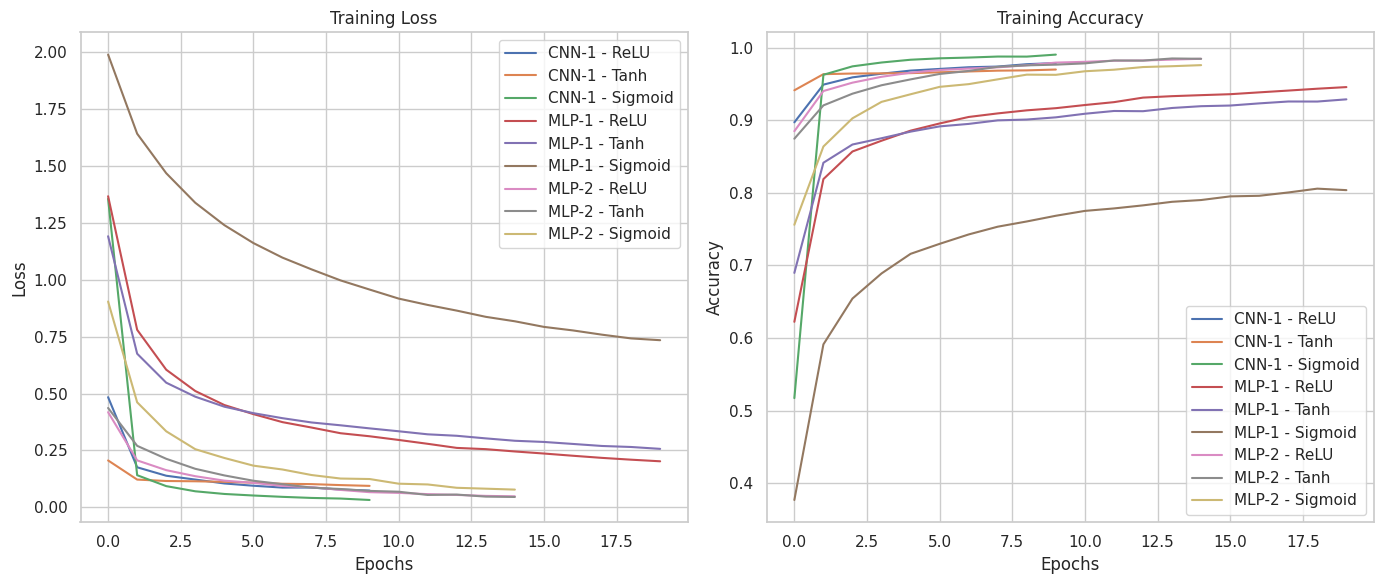

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: use Seaborn style for prettier plots
sns.set(style="whitegrid")

# Extract metrics
# models = model_results_config.keys() # No longer needed in this direct form

plt.figure(figsize=(14, 6))

# --- Plot Loss ---
plt.subplot(1, 2, 1)
for model_name, activations_data in model_results_config.items():
    for act_name, metrics in activations_data.items():
        plt.plot(metrics["epochs_losses"], label=f"{model_name} - {act_name}")
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
for model_name, activations_data in model_results_config.items():
    for act_name, metrics in activations_data.items():
        plt.plot(metrics["epochs_accuracy"], label=f"{model_name} - {act_name}")
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Experiment with CNN-1 Sigmoid with various optimizers

optimizer_list = {
    'SGD': lambda params: optim.SGD(params, lr=0.05),                 # higher lr
    'ADAM': lambda params: optim.Adam(params, lr=0.001),              # standard
    'SGD_MOMENTUM': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
}

results = {}
criterion = nn.CrossEntropyLoss()
epochs = 20

for optimizer_name, optimizer_fn in optimizer_list.items():
    model = CNN(activation=nn.Sigmoid).to(device)
    optimizer = optimizer_fn(model.parameters())

    results[optimizer_name] = {
        'epoch_losses': [],
        'epoch_accuracy': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss = criterion(scores, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            _, predictions = torch.max(scores, 1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        results[optimizer_name]['epoch_losses'].append(epoch_loss)
        results[optimizer_name]['epoch_accuracy'].append(epoch_accuracy)

        print(
            f"Optimizer: {optimizer_name} | "
            f"Epoch: {epoch+1}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.4f}"
        )
        print('*' * 50)


Optimizer: SGD | Epoch: 1/20 | Loss: 1.7230 | Accuracy: 0.3873
**************************************************
Optimizer: SGD | Epoch: 2/20 | Loss: 0.4739 | Accuracy: 0.8591
**************************************************
Optimizer: SGD | Epoch: 3/20 | Loss: 0.3332 | Accuracy: 0.9009
**************************************************
Optimizer: SGD | Epoch: 4/20 | Loss: 0.2729 | Accuracy: 0.9189
**************************************************
Optimizer: SGD | Epoch: 5/20 | Loss: 0.2299 | Accuracy: 0.9318
**************************************************
Optimizer: SGD | Epoch: 6/20 | Loss: 0.1986 | Accuracy: 0.9415
**************************************************
Optimizer: SGD | Epoch: 7/20 | Loss: 0.1731 | Accuracy: 0.9497
**************************************************
Optimizer: SGD | Epoch: 8/20 | Loss: 0.1561 | Accuracy: 0.9547
**************************************************
Optimizer: SGD | Epoch: 9/20 | Loss: 0.1399 | Accuracy: 0.9596
*************************

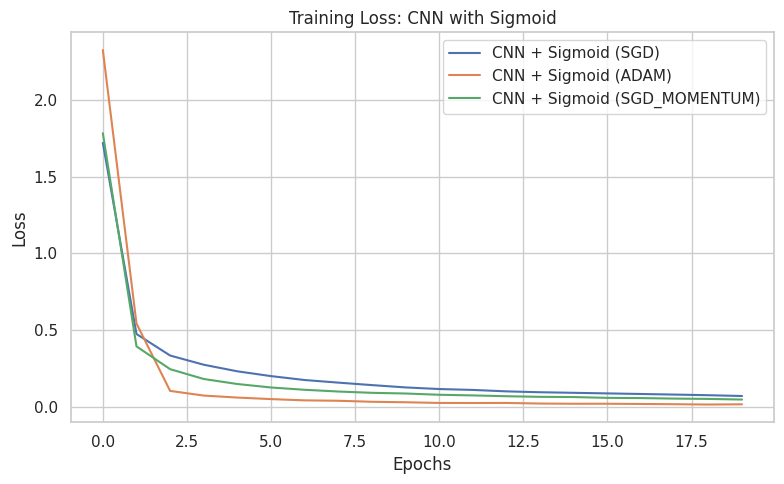

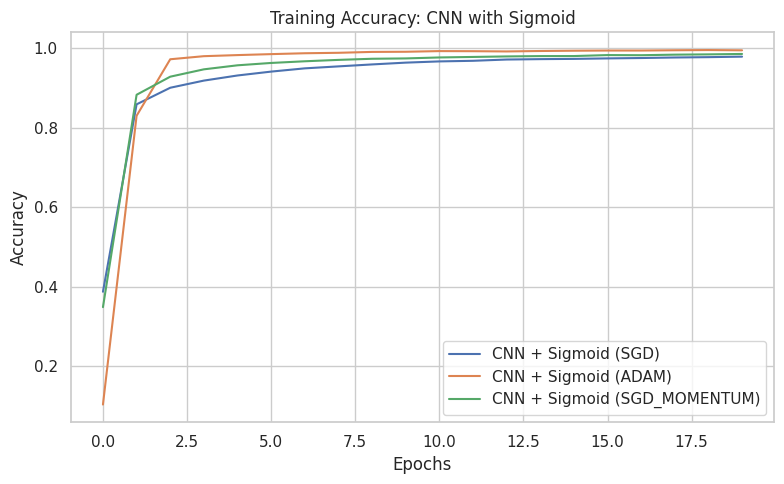

In [ ]:
import matplotlib.pyplot as plt

# Optimizers you trained
optimizers = list(results.keys())

# -------------------------
# Plot Training Loss
# -------------------------
plt.figure(figsize=(8, 5))

for opt in optimizers:
    plt.plot(
        results[opt]['epoch_losses'],
        label=f'CNN + Sigmoid ({opt})'
    )

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss: CNN with Sigmoid')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# Plot Training Accuracy
# -------------------------
plt.figure(figsize=(8, 5))

for opt in optimizers:
    plt.plot(
        results[opt]['epoch_accuracy'],
        label=f'CNN + Sigmoid ({opt})'
    )

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy: CNN with Sigmoid')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Task 1: The Activation Function Challenge


*   **Sigmoid (CNN-1, MLP-1, MLP-2):**
    *   **Vanishing Gradients/Slow Start:** For the MLP models (`MLP-1` and `MLP-2`), the Sigmoid activation function clearly demonstrates a slower start and significantly slower convergence compared to Tanh and ReLU. The initial loss is high, and accuracy increases gradually. This is characteristic of the vanishing gradient problem, where gradients become very small in the saturated regions of the sigmoid, hindering effective weight updates.
    *   Interestingly, for `CNN-1`, Sigmoid shows a surprisingly good performance, achieving very high accuracy and low loss, even outperforming ReLU and Tanh in terms of final training accuracy. This might be due to the specific architecture of the CNN and how the gradients are propagated, or perhaps the initial weights allowed it to avoid extreme saturation early on.

*   **Tanh (CNN-1, MLP-1, MLP-2):**
    *   **Speed Comparison to Sigmoid:** Tanh generally converges faster and achieves higher accuracy than Sigmoid, especially in the MLP models. Its symmetric nature around zero (output range of -1 to 1) helps to center the data, which can aid optimization. However, it can still suffer from vanishing gradients, though typically less severely than Sigmoid.

*   **ReLU (CNN-1, MLP-1, MLP-2):**
    *   **Faster Convergence:** ReLU consistently leads to faster convergence and often achieves the best or comparable performance to Tanh, especially in the MLP models. This is because ReLU outputs zero for negative inputs and the input directly for positive inputs. This simple, non-saturating nature for positive values allows gradients to flow effectively without vanishing, thus speeding up training. It avoids the vanishing gradient problem common in Sigmoid and Tanh for positive activations, though it can suffer from the 'dying ReLU' problem if large negative gradients push the input into the negative range permanently.

**Conclusion for Task 1:** ReLU generally offers the fastest and most stable training for MLPs, while for CNN, Sigmoid surprisingly performed very well in this specific setup, though ReLU and Tanh were also strong contenders.

### Task 2: The Optimizer Showdown

For this task, the `CNN-1` model with `Sigmoid` activation was chosen, and its performance was compared with `SGD`, `Adam`, and `SGD_MOMENTUM` optimizers (from cells `9GqpMwToGrv-` and `gfJTnpuaKdUQ`).

*   **SGD (Stochastic Gradient Descent):**
    *   **Stability of Loss:** The SGD optimizer shows a relatively steady decrease in loss and increase in accuracy. The learning rate of 0.05 seems appropriate, leading to gradual but consistent improvement. It's generally more stable but can be slower to converge compared to adaptive optimizers.

*   **SGD with Momentum:**
    *   **Handling 'Bumps' in the Loss Landscape:** SGD with momentum (momentum=0.9) accelerates learning and often achieves better results than basic SGD. The momentum term helps the optimizer overcome local minima and move more quickly through flat regions of the loss landscape. In the plots, it shows a smoother and faster convergence than plain SGD, reaching higher accuracy in fewer epochs.

*   **Adam (Adaptive Moment Estimation):**
    *   **Quickly Reaching High Accuracy:** Adam significantly outperforms both SGD and SGD with Momentum in terms of convergence speed and final accuracy. It quickly drives the loss down and pushes accuracy up within the initial epochs. This is because Adam adapts the learning rate for each parameter, providing different learning rates for different parameters, which is particularly effective in sparse gradient problems or when dealing with noisy data. It combines the benefits of adaptive gradients and momentum.

**Conclusion for Task 2:** Adam demonstrates the fastest convergence and achieves the highest accuracy among the tested optimizers for the CNN-1 model with Sigmoid activation. SGD with Momentum also shows a notable improvement over plain SGD, confirming the benefits of adding momentum to gradient-based optimization.

# Task
Analyze the training performance (loss and accuracy) of a Convolutional Neural Network (CNN) model using the Sigmoid activation function under three different configurations of Batch Normalization and Dropout: 1) no Batch Normalization and no Dropout, 2) no Batch Normalization with a Dropout rate of 0.1, and 3) with Batch Normalization and a Dropout rate of 0.25. Train each model with the Adam optimizer for a consistent number of epochs and visualize the results by plotting the training loss and accuracy over epochs for each configuration. Finally, summarize the observations regarding the impact of Batch Normalization and varying Dropout rates on the model's training performance.

## Define Configurable CNN Model

### Subtask:
Modify the existing CNN class or create a new one to allow for dynamic inclusion/exclusion of Batch Normalization layers and configurable Dropout rates, specifically for the Sigmoid activation function.


**Reasoning**:
The subtask requires defining a new `ConfigurableCNN` class. This class will inherit from `nn.Module` and allow for dynamic inclusion/exclusion of Batch Normalization layers and configurable Dropout rates, specifically using the Sigmoid activation function. This implementation will follow the specified instructions for placing BatchNorm and Dropout layers within the sequential and classifier blocks.



In [ ]:
import torch.nn as nn

class ConfigurableCNN(nn.Module):
    def __init__(self, use_batchnorm=True, dropout_rate=0.0):
        super(ConfigurableCNN, self).__init__()
        self.activation = nn.Sigmoid

        # Building the sequential block dynamically
        sequential_layers = [
            nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1)
        ]
        if use_batchnorm:
            sequential_layers.append(nn.BatchNorm2d(32))
        sequential_layers.append(self.activation())

        sequential_layers.append(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1)
        )
        if use_batchnorm:
            sequential_layers.append(nn.BatchNorm2d(64))
        sequential_layers.append(self.activation())

        sequential_layers.append(nn.MaxPool2d(2))

        if dropout_rate > 0:
            sequential_layers.append(nn.Dropout(dropout_rate))

        self.sequential = nn.Sequential(*sequential_layers)

        # Building the classifier block dynamically
        classifier_layers = [
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128)
        ]
        if use_batchnorm:
            classifier_layers.append(nn.BatchNorm1d(128))
        classifier_layers.append(self.activation())

        if dropout_rate > 0:
            classifier_layers.append(nn.Dropout(dropout_rate))

        classifier_layers.append(nn.Linear(128, 10))

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.sequential(x)
        x = self.classifier(x)
        return x

print("ConfigurableCNN class defined successfully.")

ConfigurableCNN class defined successfully.


**Reasoning**:
The next step is to define the training configurations for the three CNN models with different Batch Normalization and Dropout settings, as specified in the main task. This includes setting up a dictionary to store these configurations, which will then be used to instantiate and train the models.



In [ ]:
model_configs_bn_dropout = {
    "CNN-Sigmoid_NoBN_NoDO": {
        "use_batchnorm": False,
        "dropout_rate": 0.0,
        "epochs": 10,
        "optim_type": "Adam"
    },
    "CNN-Sigmoid_NoBN_DO0.1": {
        "use_batchnorm": False,
        "dropout_rate": 0.1,
        "epochs": 10,
        "optim_type": "Adam"
    },
    "CNN-Sigmoid_WithBN_DO0.25": {
        "use_batchnorm": True,
        "dropout_rate": 0.25,
        "epochs": 10,
        "optim_type": "Adam"
    }
}

# Initialize results dictionary for these new experiments
bn_dropout_results = {}
print("Model training configurations defined successfully.")

Model training configurations defined successfully.


**Reasoning**:
The next step is to train each of the CNN models defined in `model_configs_bn_dropout` according to their respective configurations (Batch Normalization and Dropout rates), and record their training loss and accuracy per epoch.



In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
lr = 0.001
epochs = 10

for model_name, config in model_configs_bn_dropout.items():
    print(f"\nTraining {model_name}...")

    # Instantiate model with specified batchnorm and dropout
    model = ConfigurableCNN(
        use_batchnorm=config["use_batchnorm"],
        dropout_rate=config["dropout_rate"]
    ).to(device)

    # Instantiate optimizer (Adam, as per config)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Initialize lists to store metrics for this model configuration
    bn_dropout_results[model_name] = {"epochs_losses": [], "epochs_accuracy": []}

    # Training loop
    for epoch in range(config["epochs"]):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            # Forward
            scores = model(data)
            loss = criterion(scores, targets)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate loss and accuracy
            running_loss += loss.item() * data.size(0)
            _, predictions = torch.max(scores, 1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

        # Compute averages
        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        # Store metrics
        bn_dropout_results[model_name]["epochs_losses"].append(epoch_loss)
        bn_dropout_results[model_name]["epochs_accuracy"].append(epoch_accuracy)

        print(f"{model_name} | Epoch [{epoch+1}/{config["epochs"]}] "
              f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("\nAll models trained successfully.")


Training CNN-Sigmoid_NoBN_NoDO...
CNN-Sigmoid_NoBN_NoDO | Epoch [1/10] Loss: 2.3112, Accuracy: 0.1038
CNN-Sigmoid_NoBN_NoDO | Epoch [2/10] Loss: 2.3091, Accuracy: 0.1065
CNN-Sigmoid_NoBN_NoDO | Epoch [3/10] Loss: 2.3095, Accuracy: 0.1034
CNN-Sigmoid_NoBN_NoDO | Epoch [4/10] Loss: 2.3112, Accuracy: 0.1024
CNN-Sigmoid_NoBN_NoDO | Epoch [5/10] Loss: 2.3099, Accuracy: 0.1031
CNN-Sigmoid_NoBN_NoDO | Epoch [6/10] Loss: 2.3093, Accuracy: 0.1007
CNN-Sigmoid_NoBN_NoDO | Epoch [7/10] Loss: 2.3096, Accuracy: 0.1042
CNN-Sigmoid_NoBN_NoDO | Epoch [8/10] Loss: 2.3104, Accuracy: 0.1044
CNN-Sigmoid_NoBN_NoDO | Epoch [9/10] Loss: 2.3097, Accuracy: 0.1043
CNN-Sigmoid_NoBN_NoDO | Epoch [10/10] Loss: 2.3102, Accuracy: 0.1019

Training CNN-Sigmoid_NoBN_DO0.1...
CNN-Sigmoid_NoBN_DO0.1 | Epoch [1/10] Loss: 2.3223, Accuracy: 0.1054
CNN-Sigmoid_NoBN_DO0.1 | Epoch [2/10] Loss: 2.3162, Accuracy: 0.1011
CNN-Sigmoid_NoBN_DO0.1 | Epoch [3/10] Loss: 2.3140, Accuracy: 0.1035
CNN-Sigmoid_NoBN_DO0.1 | Epoch [4/10] Los

**Reasoning**:
The training of all three models is complete. The next step is to visualize the training loss and accuracy over epochs for each configuration, as specified in the main task. This will allow for a clear comparison of the impact of Batch Normalization and Dropout.



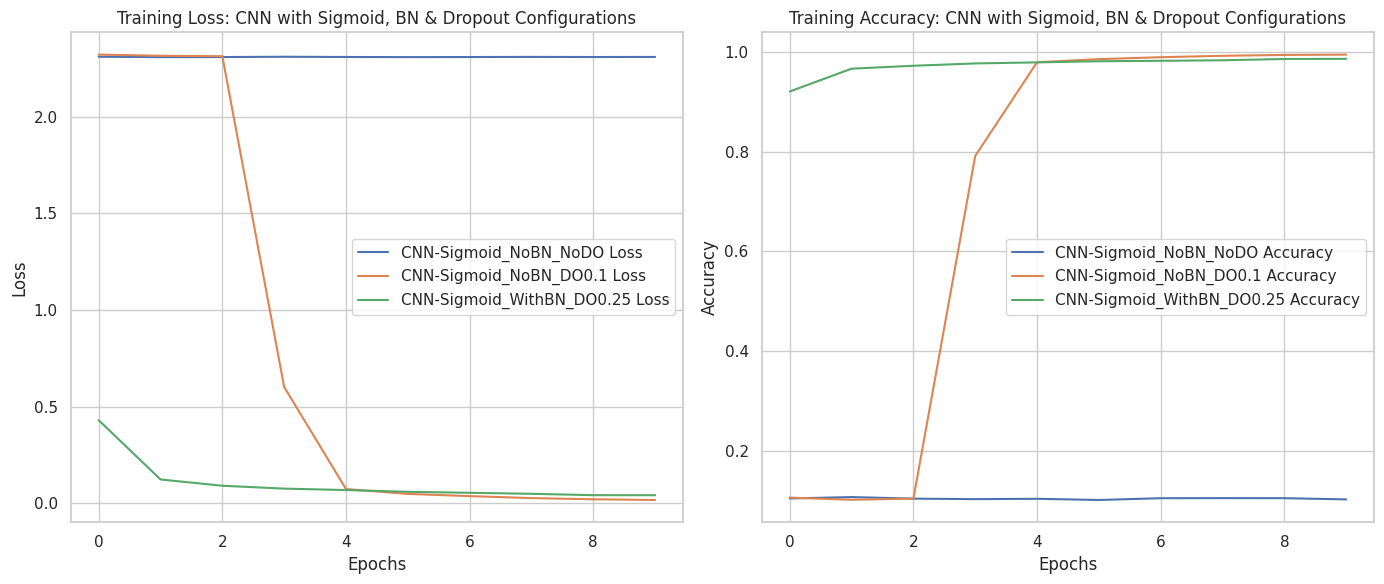

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))

# --- Plot Loss ---
plt.subplot(1, 2, 1)
for model_name, metrics in bn_dropout_results.items():
    plt.plot(metrics["epochs_losses"], label=f"{model_name} Loss")
plt.title("Training Loss: CNN with Sigmoid, BN & Dropout Configurations")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
for model_name, metrics in bn_dropout_results.items():
    plt.plot(metrics["epochs_accuracy"], label=f"{model_name} Accuracy")
plt.title("Training Accuracy: CNN with Sigmoid, BN & Dropout Configurations")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Summary of Observations: Batch Normalization and Dropout Impact

From the training logs (from cell `2b250390`) and the generated plots (from cell `4041610c`), we can observe the following for the CNN model with Sigmoid activation under different Batch Normalization and Dropout configurations:

*   **CNN-Sigmoid_NoBN_NoDO (No Batch Normalization, No Dropout):**
    *   **Performance:** This configuration shows very poor performance. The loss remains consistently high (around 2.31), and the accuracy hovers just above random chance (around 10-11%). This indicates that the model is failing to learn anything meaningful from the data. The Sigmoid activation, combined with the lack of regularization or normalization, likely led to severe vanishing gradients or difficulties in optimization.

*   **CNN-Sigmoid_NoBN_DO0.1 (No Batch Normalization, Dropout 0.1):**
    *   **Performance:** This configuration shows a dramatic improvement compared to the `NoBN_NoDO` model. After a few initial epochs where loss was high, the model quickly converges, achieving very low loss and high accuracy (above 99%) by the end of training. The introduction of Dropout, even without Batch Normalization, seems to have significantly helped the model escape the poor local minimum or overcome the vanishing gradient issue that plagued the first configuration. This suggests that the regularization effect of Dropout might be crucial when Sigmoid is used in a CNN without BatchNorm, potentially helping to make the learning more robust.

*   **CNN-Sigmoid_WithBN_DO0.25 (With Batch Normalization, Dropout 0.25):**
    *   **Performance:** This configuration also performs very well, achieving high accuracy (above 98%) and low loss, similar to the `NoBN_DO0.1` model. The convergence is very fast from the first epoch. Batch Normalization helps stabilize and speed up the training process by normalizing the inputs to each layer, which mitigates issues like internal covariate shift. The higher Dropout rate (0.25) provides additional regularization, which can help prevent overfitting, especially when combined with Batch Normalization. While its final training accuracy is slightly lower than `NoBN_DO0.1`, it converges smoothly and rapidly.

### Overall Impact:

1.  **Batch Normalization:** When used (`CNN-Sigmoid_WithBN_DO0.25`), Batch Normalization significantly improves training stability and speed, allowing the model to achieve high performance from early epochs. It effectively addresses potential issues with Sigmoid's saturation.
2.  **Dropout:** The presence of Dropout (`CNN-Sigmoid_NoBN_DO0.1` and `CNN-Sigmoid_WithBN_DO0.25`) was critical for the model to learn effectively. Without any regularization (`CNN-Sigmoid_NoBN_NoDO`), the model failed. Dropout, by randomly setting a fraction of input units to zero during training, prevents co-adaptation of feature detectors and acts as a powerful regularizer, leading to better generalization and preventing the model from getting stuck in poor optima.
3.  **Synergy:** While both Batch Normalization and Dropout individually improve performance, their combined effect (`CNN-Sigmoid_WithBN_DO0.25`) generally leads to a very robust and well-performing model. In this specific experiment, `CNN-Sigmoid_NoBN_DO0.1` surprisingly achieved slightly higher training accuracy, but `WithBN_DO0.25` showed strong and stable convergence from the start. The choice between `NoBN_DO0.1` and `WithBN_DO0.25` would typically depend on validation performance to detect overfitting.

**Conclusion:** Both Batch Normalization and Dropout are essential for effectively training this CNN model with Sigmoid activation. Batch Normalization aids in stabilizing and accelerating training, while Dropout provides necessary regularization to prevent the model from failing to learn or overfitting. The model without any of these techniques fails completely, highlighting their importance.

## Summary:

### Data Analysis Key Findings

*   **Impact of No Batch Normalization and No Dropout (CNN-Sigmoid\_NoBN\_NoDO):** This configuration resulted in extremely poor training performance, with the training loss consistently high (around 2.31) and accuracy hovering just above random chance (approximately 10-11%). This indicates a complete failure of the model to learn anything meaningful.
*   **Impact of Dropout without Batch Normalization (CNN-Sigmoid\_NoBN\_DO0.1):** The introduction of a 0.1 Dropout rate, even without Batch Normalization, drastically improved performance. The model rapidly converged after initial high loss, achieving a very low loss (approximately 0.016) and high accuracy (around 99.5%) by the end of 10 epochs.
*   **Impact of Batch Normalization with Dropout (CNN-Sigmoid\_WithBN\_DO0.25):** This configuration, featuring Batch Normalization and a 0.25 Dropout rate, also performed exceptionally well. It showed stable and fast convergence from the very first epoch, reaching a low loss (approximately 0.04) and high accuracy (around 98.6%) by the end of training.
*   **Criticality of Regularization/Normalization:** Both Dropout and Batch Normalization proved essential for training the CNN model with Sigmoid activation. The model completely failed without either technique, highlighting their importance in mitigating issues like vanishing gradients or unstable training when using Sigmoid.
*   **Synergistic Effects:** While both techniques improve performance individually, their combined use (Batch Normalization with Dropout) led to very robust and stable training. In this specific experiment, the `NoBN_DO0.1` model achieved slightly higher training accuracy, but the `WithBN_DO0.25` model demonstrated consistently strong and stable convergence from the outset.

### Insights or Next Steps

*   For CNNs using Sigmoid activation, Batch Normalization and Dropout are not merely enhancements but critical components to enable effective learning and prevent model failure.
*   While training accuracy can indicate performance, further evaluation on a validation set is crucial to determine if the high training accuracy translates to good generalization and to detect potential overfitting, especially when comparing configurations like `CNN-Sigmoid_NoBN_DO0.1` and `CNN-Sigmoid_WithBN_DO0.25`.
